In [1]:
# -*- coding: utf-8 -*-

"""
@Time        : 7/1/2023
@Author      : purmortal
@File        : plot_gist_aggregation
@Description : 10% migration-efficiency face-on model
"""

import sys
from pathlib import Path

# ================================================================================================
# MAIN PROJECT DIRECTORIES
# ================================================================================================

project_root = Path(
    "/Users/selilium/galcraft_test/test_gistplot"
)

code_dir = project_root / "code"

# Make the Python scripts inside code/ importable.
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

print(f"Project root: {project_root}")
print(f"Importing modules from: {code_dir}")


# ================================================================================================
# IMPORT PROJECT MODULES
# ================================================================================================

from utils import *
import gist_plot as gist_plot
import gist_mass_fraction_plot as gist_mass_fraction_plot
from weights_loader import weights


# ================================================================================================
# IMPORT GENERAL PACKAGES
# ================================================================================================

import matplotlib

from multiprocessing import Pool
from astropy.io import fits
from astropy.table import Table, vstack
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
from scipy.stats import pearsonr
from spectres import spectres

import numpy as np
import os


# ================================================================================================
# FACE-ON 10% MIGRATION-EFFICIENCY MODEL PATHS
# ================================================================================================

# faceon_L0x0p1 = 10% migration efficiency.
faceon_model_dir = (
    project_root
    / "faceon"
    / "faceon_L0x0p1"
)

# Parent GIST directory for this face-on model.
faceon_gist_dir = (
    faceon_model_dir
    / "gist"
)

# Regularization R = 1 GIST run.
cube_gist_run = "resultsRevisedMEr1"

# IMPORTANT:
# The loader expects cube_gist_path to be the directory directly
# above the resultsRevisedMEr1 folder and to end with "/".
cube_gist_path = str(faceon_gist_dir) + "/"

# Mass-weighted stellar-population fractions.
fraction_type = "mass fraction"


# ================================================================================================
# FIGURE OUTPUT PATH
# ================================================================================================

fig_path = (
    project_root
    / "figs"
    / "faceon"
    / "faceon_L0x0p1"
    / cube_gist_run
)

fig_path.mkdir(
    parents=True,
    exist_ok=True
)

# Convert to a string for compatibility with the notebook.
fig_path = str(fig_path)


# ================================================================================================
# VERIFY REQUIRED FACE-ON FILES
# ================================================================================================

run_dir = (
    faceon_gist_dir
    / cube_gist_run
)

ppxf_weights_file = (
    run_dir
    / f"{cube_gist_run}_sfh-weights.fits"
)

true_weights_file = (
    run_dir
    / f"{cube_gist_run}_sfh-weights_true_mw.fits"
)

table_file = (
    run_dir
    / f"{cube_gist_run}_table.fits"
)

required_files = {
    "pPXF weights": ppxf_weights_file,
    "true mass-weighted weights": true_weights_file,
    "GIST spatial table": table_file,
}

missing_files = [
    str(filepath)
    for filepath in required_files.values()
    if not filepath.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required 10% face-on files were not found:\n\n"
        + "\n".join(missing_files)
    )


# ================================================================================================
# CLEAN CONFIRMATION OUTPUT
# ================================================================================================

print("\n" + "=" * 90)
print("FACE-ON 10% MIGRATION MODEL SETUP CONFIRMED")
print("=" * 90)

print(
    "\nModel:"
    "\nfaceon_L0x0p1 = 10% migration efficiency"
)

print(
    "\nRegularization:"
    "\nresultsRevisedMEr1 = R = 1"
)

print(
    f"\ncube_gist_path:\n{cube_gist_path}"
)

print(
    f"\ncube_gist_run:\n{cube_gist_run}"
)

print(
    f"\nFigure path:\n{fig_path}"
)

print("\nRequired files found:")

for label, filepath in required_files.items():
    print(
        f"  ✓ {label}: {filepath.name}"
    )

print("\nCell #1 completed successfully.")

Project root: /Users/selilium/galcraft_test/test_gistplot
Importing modules from: /Users/selilium/galcraft_test/test_gistplot/code

FACE-ON 10% MIGRATION MODEL SETUP CONFIRMED

Model:
faceon_L0x0p1 = 10% migration efficiency

Regularization:
resultsRevisedMEr1 = R = 1

cube_gist_path:
/Users/selilium/galcraft_test/test_gistplot/faceon/faceon_L0x0p1/gist/

cube_gist_run:
resultsRevisedMEr1

Figure path:
/Users/selilium/galcraft_test/test_gistplot/figs/faceon/faceon_L0x0p1/resultsRevisedMEr1

Required files found:
  ✓ pPXF weights: resultsRevisedMEr1_sfh-weights.fits
  ✓ true mass-weighted weights: resultsRevisedMEr1_sfh-weights_true_mw.fits
  ✓ GIST spatial table: resultsRevisedMEr1_table.fits

Cell #1 completed successfully.


In [2]:
fig_path_run = fig_path  + cube_gist_run
print (fig_path, cube_gist_run, fig_path_run)
if os.path.exists(fig_path_run) == False:
    os.mkdir(fig_path_run)

cube_gist_run_path = cube_gist_path + cube_gist_run + '/'
filename = cube_gist_run_path + cube_gist_run

cmap_color = 'sauron'

/Users/selilium/galcraft_test/test_gistplot/figs/faceon/faceon_L0x0p1/resultsRevisedMEr1 resultsRevisedMEr1 /Users/selilium/galcraft_test/test_gistplot/figs/faceon/faceon_L0x0p1/resultsRevisedMEr1resultsRevisedMEr1


# Weighted average

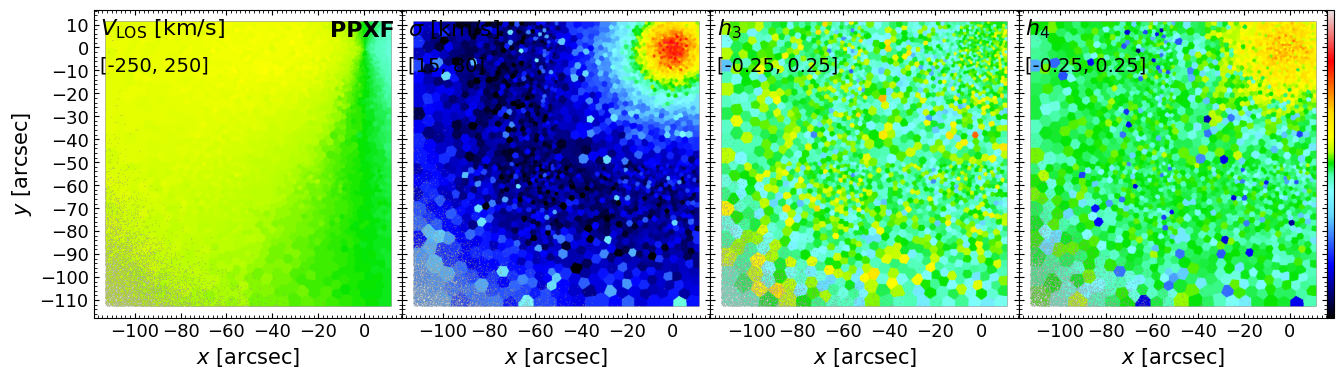

In [3]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# KIN
vminmax = np.array([[[-250, 250], [15, 80], [-0.25, 0.25], [-0.25, 0.25]]])
result_l = gist_plot.read_results_kin(filename, [''])
fig_kin = gist_plot.plot_kin(filename, ['PPXF'], result_l=result_l, vminmax=vminmax,
                use_vminmax=[True], residual=[False], cmap_l=[cmap_color] * len(result_l))
fig_kin.savefig(fig_path_run + '/test_kin_' + cube_gist_run + '.pdf', dpi=500, pad_inches=0.02, bbox_inches='tight')

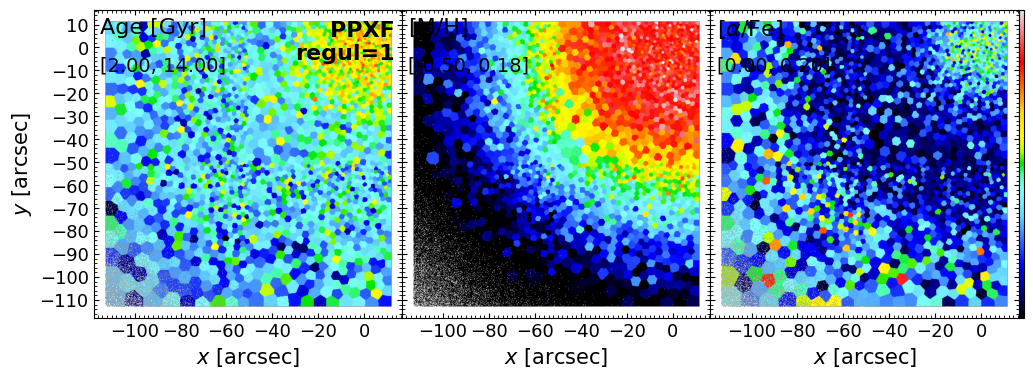

In [4]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# SFH
sfh_header = fits.open(filename + '_sfh.fits')[1].header
if sfh_header['HIERARCH REGUL_ERR'] == None:
    regul = 0
else:
    regul = 1 / sfh_header['HIERARCH REGUL_ERR']


vminmax = np.array([[[2, 14], [-0.5, 0.18], [0, 0.2]]])
result_l = gist_plot.read_results_sfh(filename, flag=['SFH'], suffix=[''])
fig_sfh = gist_plot.plot_sfh(filename, ['PPXF\nregul=' + str(int(regul))],
                             result_l=result_l, vminmax=vminmax, use_vminmax=[True],
                             residual=[False], cmap_l=[cmap_color] * len(result_l))
res_age_array = np.unique(result_l[-1][:, 0])
res_metal_array = np.unique(result_l[-1][:, 1])
res_alpha_array = np.unique(result_l[-1][:, 2])
fig_sfh.savefig(fig_path_run + '/test_sfh_' + cube_gist_run + '.pdf', dpi=500, pad_inches=0.02, bbox_inches='tight')

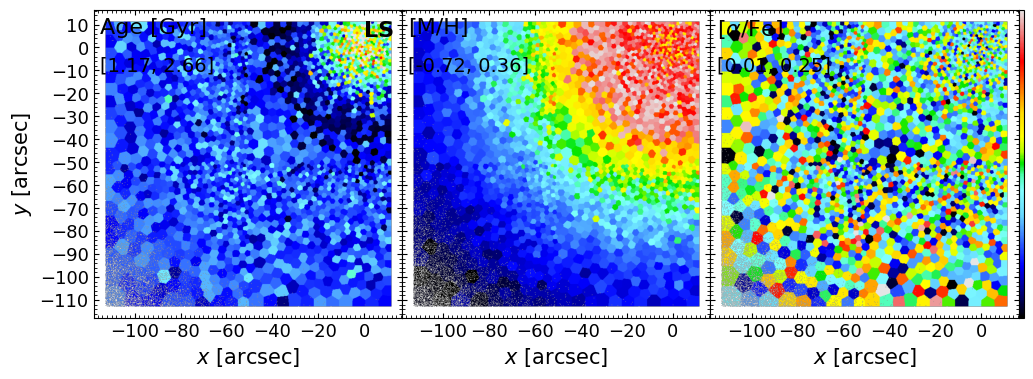

In [5]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# LS
if os.path.exists(filename + '_ls_AdapRes.fits'):
    result_l = gist_plot.read_results_sfh(filename, flag=['LS'], suffix=[''])
    fig_ls = gist_plot.plot_sfh(filename, ['LS'], result_l=result_l, use_vminmax=[False], cmap_l=[cmap_color] * len(result_l))
    fig_ls.savefig(fig_path_run + '/test_sfh_ls_' + cube_gist_run + '.pdf', dpi=500, pad_inches=0.02, bbox_inches='tight')

# Global Mass distribution

In [6]:
ppxf_weights = weights(cube_gist_path, cube_gist_run, mode='ppxf', fraction_type=fraction_type)
true_weights = weights(cube_gist_path, cube_gist_run, mode='true', fraction_type=fraction_type)

# To Michael:
# ppxf_weights are the weights that obtained from PPXF spectral fitting
# true_weights here are the weights that I calculated by myself as the "true" value 
# in the GalCraft paper to compare with PPXF weights, you can change it to your nGIST
# results by changing the 'cube_gist_path' and 'cube_gist_run', mode='ppxf' keywords 

/Users/selilium/galcraft_test/test_gistplot/code/weights_loader.py:228: RuntimeWarning: invalid value encountered in divide
  weights_bulge = weights_bulge / np.nansum(weights_forsum_bulge)
/Users/selilium/galcraft_test/test_gistplot/code/weights_loader.py:229: RuntimeWarning: invalid value encountered in divide
  weights_thin = weights_thin / np.nansum(weights_forsum_thin)
/Users/selilium/galcraft_test/test_gistplot/code/weights_loader.py:230: RuntimeWarning: invalid value encountered in divide
  weights_thick = weights_thick / np.nansum(weights_forsum_thick)
/Users/selilium/galcraft_test/test_gistplot/code/weights_loader.py:231: RuntimeWarning: invalid value encountered in divide
  weights_innerthin = weights_innerthin / np.nansum(weights_forsum_innerthin)
/Users/selilium/galcraft_test/test_gistplot/code/weights_loader.py:232: RuntimeWarning: invalid value encountered in divide
  weights_outerthin = weights_outerthin / np.nansum(weights_forsum_outerthin)
/Users/selilium/galcraft_test

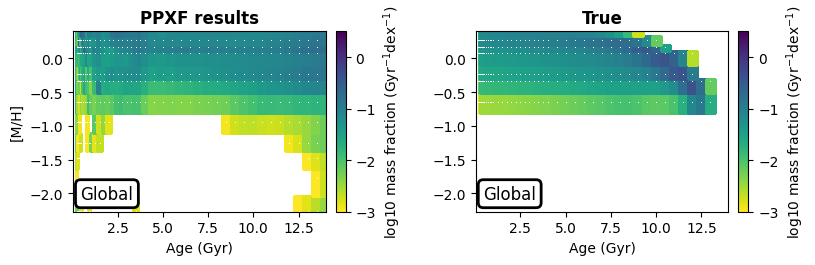

In [7]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# mass/light-fraction distribution



fig_mft = gist_mass_fraction_plot.plot_weights_2d_cases([[ppxf_weights.log_wdf], [true_weights.log_wdf]],
                                [ppxf_weights.age_grid_2d[:, :, 0], true_weights.age_grid_2d[:, :, 0]],
                                [ppxf_weights.metal_grid_2d[:, :, 0], true_weights.metal_grid_2d[:, :, 0]],
                                ['Global'], ['PPXF results', 'True'], vmin=-3, vmax=0.5,
                                axes_pad=[1.3, 0.3], cbar_mode='each', cbar_location='right', cbar_pad=0.1,
                                cb_label=r'log10 %s ($\rm Gyr^{-1} dex^{-1}$)' % fraction_type, cmap='viridis_r', nodots=False)
fig_mft.tight_layout(pad=0.15)
fig_mft.savefig(fig_path_run + '/2dmfd_global_massperGyrperdex_linage_metal_' + cube_gist_run + '.pdf', dpi=500)

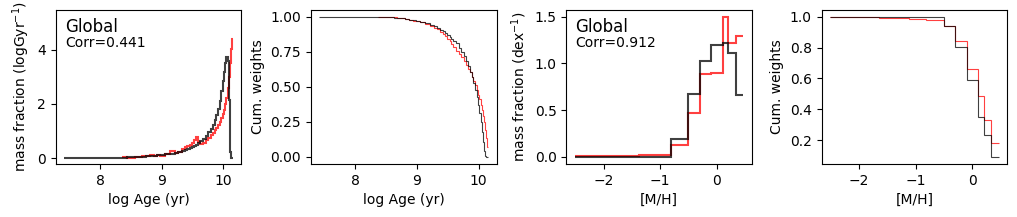

In [8]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Total star formation history and metallicity distribution perlogage, logage
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.cumulative_weights_2d],
                                          [true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb_log[:, 0, 0], true_weights.yyb_log[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['logage_stairs', 'logage_cum', 'metal_stairs', 'metal_cum'],
                            perbinsize_list=['log', None, True, None],
                            logmass_list=[False, False, False, False],
                            show_corr_list=[True, False, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Global'],
                            direction='col', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.7)
fig.savefig(fig_path_run + '/1dmfd_global_weightsperlogGyr_logage_metal_' + cube_gist_run + '.pdf', dpi=500)

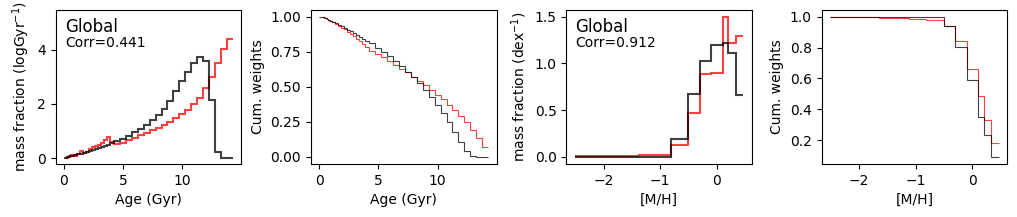

In [9]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Total star formation history and metallicity distribution perlogage
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.cumulative_weights_2d],
                                          [true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb_log[:, 0, 0], true_weights.yyb_log[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['age_stairs', 'age_cum', 'metal_stairs', 'metal_cum'],
                            perbinsize_list=['log', None, True, None],
                            logmass_list=[False, False, False, False],
                            show_corr_list=[True, False, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Global'],
                            direction='col', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.7)
fig.savefig(fig_path_run + '/1dmfd_global_weightsperlogGyr_linage_metal_' + cube_gist_run + '.pdf', dpi=500)

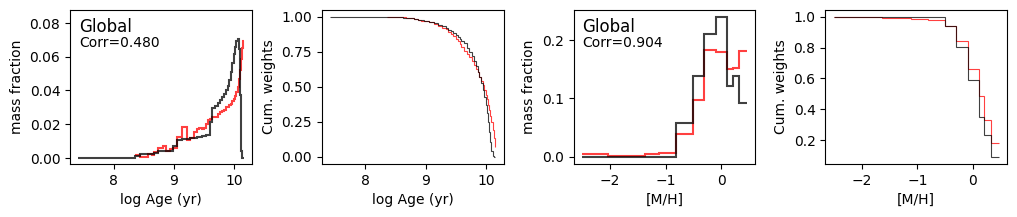

In [10]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Total star formation history and metallicity distribution in log age space
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.cumulative_weights_2d],
                                          [true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb[:, 0, 0], true_weights.yyb[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['logage_stairs', 'logage_cum', 'metal_stairs', 'metal_cum'],
                            perbinsize_list=[False, None, False, None],
                            logmass_list=[False, False, False, False],
                            show_corr_list=[True, False, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Global'],
                            direction='col', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.7)
fig.savefig(fig_path_run + '/1dmfd_global_weights_logage_metal_' + cube_gist_run + '.pdf', dpi=500)

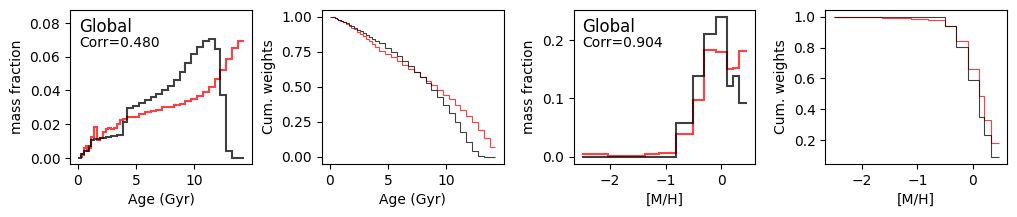

In [11]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Total star formation history and metallicity distribution
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.cumulative_weights_2d],
                                          [true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb[:, 0, 0], true_weights.yyb[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['age_stairs', 'age_cum', 'metal_stairs', 'metal_cum'],
                            perbinsize_list=[False, None, False, None],
                            logmass_list=[False, False, False, False],
                            show_corr_list=[True, False, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Global'],
                            direction='col', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.7)
fig.savefig(fig_path_run + '/1dmfd_global_weights_linage_metal_' + cube_gist_run + '.pdf', dpi=500)

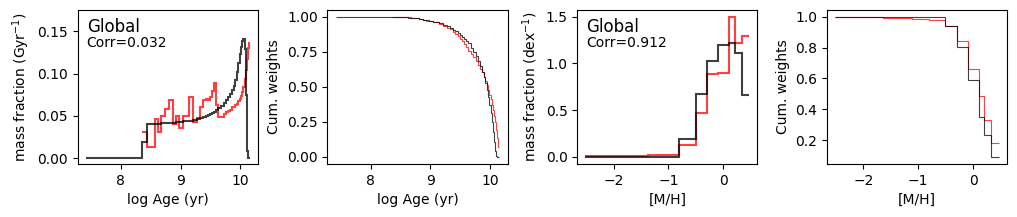

In [12]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Plot same figure without dividing binsize
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.cumulative_weights_2d],
                                          [true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb[:, 0, 0], true_weights.yyb[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['logage_stairs', 'logage_cum', 'metal_stairs', 'metal_cum'],
                            perbinsize_list=[True, None, True, None],
                            logmass_list=[False, False, False, False],
                            show_corr_list=[True, False, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Global'],
                            direction='col', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.7)
fig.savefig(fig_path_run + '/1dmfd_global_weightsperGyr_logage_metal_' + cube_gist_run + '.pdf', dpi=500)

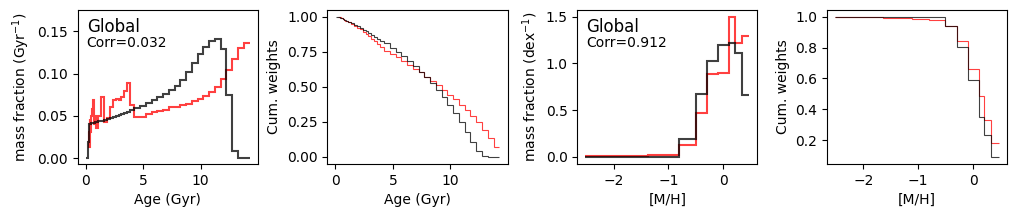

In [13]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Plot same figure without dividing binsize
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.cumulative_weights_2d],
                                          [true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb[:, 0, 0], true_weights.yyb[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['age_stairs', 'age_cum', 'metal_stairs', 'metal_cum'],
                            perbinsize_list=[True, None, True, None],
                            logmass_list=[False, False, False, False],
                            show_corr_list=[True, False, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Global'],
                            direction='col', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.7)
fig.savefig(fig_path_run + '/1dmfd_global_weightsperGyr_linage_metal_' + cube_gist_run + '.pdf', dpi=500)

# Mass distribution of different components

/var/folders/2_/44rr6rk915g7v4b1dstqddh40000gn/T/ipykernel_1992/3790648592.py:11: RuntimeWarning: divide by zero encountered in log
  ax.imshow(np.flip(np.log(ppxf_weights.flux_reshape), axis=0), cmap='gist_yarg', vmax=np.nanpercentile(np.log(ppxf_weights.flux_reshape), 99),


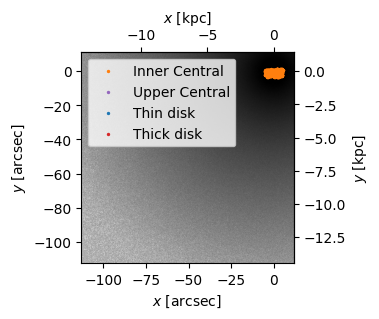

In [14]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Plot components distribution

def arcsec2dist(arc):
    return 26500 * arc / 3600 * np.pi / 180

def dist2arcsec(dist):
    return dist * 180 / np.pi * 3600 / 26500

fig, ax = plt.subplots(1, 1, figsize=[6, 3])
ax.imshow(np.flip(np.log(ppxf_weights.flux_reshape), axis=0), cmap='gist_yarg', vmax=np.nanpercentile(np.log(ppxf_weights.flux_reshape), 99),
          extent=[np.min(ppxf_weights.results_table['X']) - ppxf_weights.pixelsize / 2, np.max(ppxf_weights.results_table['X']) + ppxf_weights.pixelsize / 2,
                  np.min(ppxf_weights.results_table['Y']) - ppxf_weights.pixelsize / 2, np.max(ppxf_weights.results_table['Y']) + ppxf_weights.pixelsize / 2])
ax.scatter(ppxf_weights.results_nuclear['X'], ppxf_weights.results_nuclear['Y'], s=2, c='tab:orange', label='Inner Central')
ax.scatter(ppxf_weights.results_bulge['X'], ppxf_weights.results_bulge['Y'], s=2, c='tab:purple', label='Upper Central')
ax.scatter(ppxf_weights.results_thin['X'], ppxf_weights.results_thin['Y'], s=2, c='tab:blue', label='Thin disk')
ax.scatter(ppxf_weights.results_thick['X'], ppxf_weights.results_thick['Y'], s=2, c='tab:red', label='Thick disk')
ax.set_xlabel(r'$x$ [arcsec]')
ax.set_ylabel(r'$y$ [arcsec]')
secaxx = ax.secondary_xaxis('top', functions=(arcsec2dist, dist2arcsec))
secaxx.set_xlabel(r'$x$ [kpc]')
secaxy = ax.secondary_yaxis('right', functions=(arcsec2dist, dist2arcsec))
secaxy.set_ylabel(r'$y$ [kpc]')
plt.legend()
plt.tight_layout(pad=0.01)
plt.savefig(fig_path_run + '/galaxy_components_' + cube_gist_run + '.png', dpi=500)

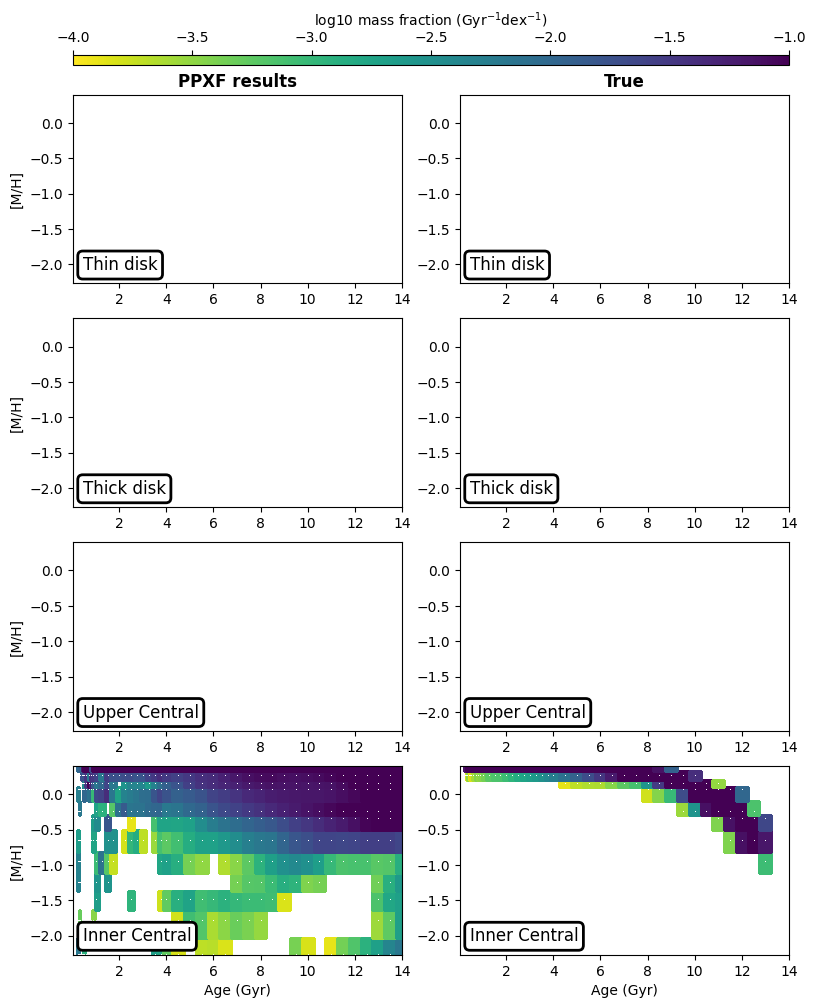

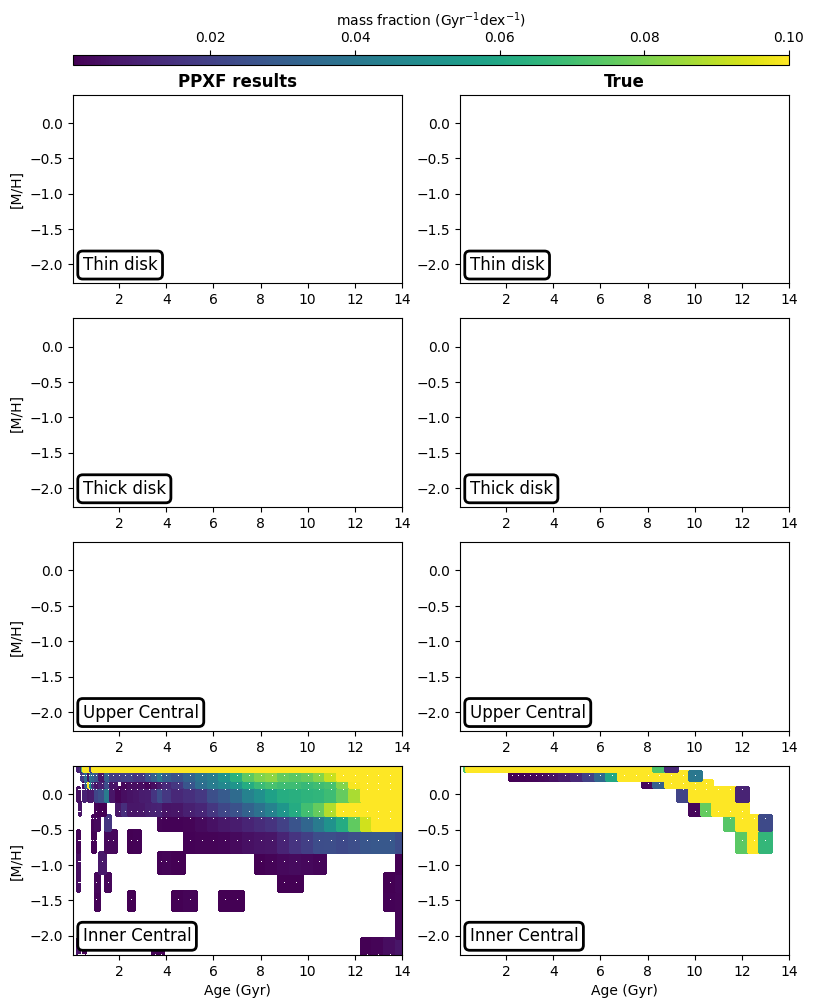

In [15]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
fig = gist_mass_fraction_plot.plot_weights_2d_cases([[ppxf_weights.log_wdf_thin, ppxf_weights.log_wdf_thick, ppxf_weights.log_wdf_bulge, ppxf_weights.log_wdf_nuclear],
                             [true_weights.log_wdf_thin, true_weights.log_wdf_thick, true_weights.log_wdf_bulge, true_weights.log_wdf_nuclear]],
                            [ppxf_weights.age_grid_2d[:, :, 0], true_weights.age_grid_2d[:, :, 0]],
                            [ppxf_weights.metal_grid_2d[:, :, 0], true_weights.metal_grid_2d[:, :, 0]],
                            ['Thin disk', 'Thick disk', 'Upper Central', 'Inner Central'], ['PPXF results', 'True'], vmin= -4, vmax= -1, 
                            axes_pad=(0.58, 0.35), cbar_mode='single', cbar_location='top', cbar_pad=0.3,
                            cb_label=r'log10 %s ($\rm Gyr^{-1} dex^{-1}$)' % fraction_type, cmap='viridis_r', nodots=False)
fig.subplots_adjust(left=0.085, bottom=0.05, right=0.980, top=0.95)
fig.savefig(fig_path_run + '/2dmfd_components_logweightsperGyrperdex_linage_metal_' + cube_gist_run + '.pdf', dpi=500)

fig = gist_mass_fraction_plot.plot_weights_2d_cases([[ppxf_weights.wdf_thin, ppxf_weights.wdf_thick, ppxf_weights.wdf_bulge, ppxf_weights.wdf_nuclear],
                             [true_weights.wdf_thin, true_weights.wdf_thick, true_weights.wdf_bulge, true_weights.wdf_nuclear]],
                            [ppxf_weights.age_grid_2d[:, :, 0], true_weights.age_grid_2d[:, :, 0]],
                            [ppxf_weights.metal_grid_2d[:, :, 0], true_weights.metal_grid_2d[:, :, 0]],
                            ['Thin disk', 'Thick disk', 'Upper Central', 'Inner Central'], ['PPXF results', 'True'], vmin=0.001, vmax=0.1,
                            axes_pad=(0.58, 0.35), cbar_mode='single', cbar_location='top', cbar_pad=0.3,
                            cb_label=r'%s ($\rm Gyr^{-1} dex^{-1}$)' % fraction_type, cmap='viridis', nodots=False)
fig.subplots_adjust(left=0.085, bottom=0.05, right=0.980, top=0.95)
fig.savefig(fig_path_run + '/2dmfd_components_weightsperGyrperdex_linage_metal_' + cube_gist_run + '.pdf', dpi=500)

In [16]:
print("wdf_thin:", ppxf_weights.wdf_thin.shape)
print("age grid:", ppxf_weights.age_grid_2d.shape)
print("metal grid:", ppxf_weights.metal_grid_2d.shape)


wdf_thin: (43, 12)
age grid: (43, 12, 2)
metal grid: (43, 12, 2)


In [17]:
for attr in dir(ppxf_weights):
    try:
        arr = getattr(ppxf_weights, attr)
        if isinstance(arr, np.ndarray):
            print(attr, arr.shape)
    except:
        pass


age_grid_2d (43, 12, 2)
alpha_grid_2d (43, 12, 2)
bin_areas (28,)
bin_edges (29,)
cumulative_weights_2d (43, 12, 2)
flux_reshape (621, 622)
grid_area_2d (43, 12, 2)
grid_area_2d_log (43, 12, 2)
log_wdf (43, 12)
log_wdf_bulge (43, 12)
log_wdf_innerthick (43, 12)
log_wdf_innerthin (43, 12)
log_wdf_nuclear (43, 12)
log_wdf_outerthick (43, 12)
log_wdf_outerthin (43, 12)
log_wdf_thick (43, 12)
log_wdf_thin (43, 12)
mean_alpha_grids_bulge (43, 12)
mean_alpha_grids_nuclear (43, 12)
mean_alpha_grids_thick (43, 12)
mean_alpha_grids_thin (43, 12)
metal (12,)
metal_bulge (12,)
metal_grid_2d (43, 12, 2)
metal_nuclear (12,)
metal_thick (12,)
metal_thin (12,)
original_weights_values (2619, 1032)
reg_dim (3,)
statistic_sfh (28,)
statistic_sfh_bulge (28,)
statistic_sfh_innerthick (28,)
statistic_sfh_innerthin (28,)
statistic_sfh_nuclear (28,)
statistic_sfh_outerthick (28,)
statistic_sfh_outerthin (28,)
statistic_sfh_thick (28,)
statistic_sfh_thin (28,)
wdf (43, 12)
wdf_bulge (43, 12)
wdf_innerthick (4

/Users/selilium/galcraft_test/test_gistplot/code/gist_mass_fraction_plot.py:188: RuntimeWarning: All-NaN slice encountered
  max_mass = np.max([np.nanmax(mass_frac[age_grid > 1]) for mass_frac, age_grid in zip(mass_frac_list, age_grid_list)])


ValueError: Axis limits cannot be NaN or Inf

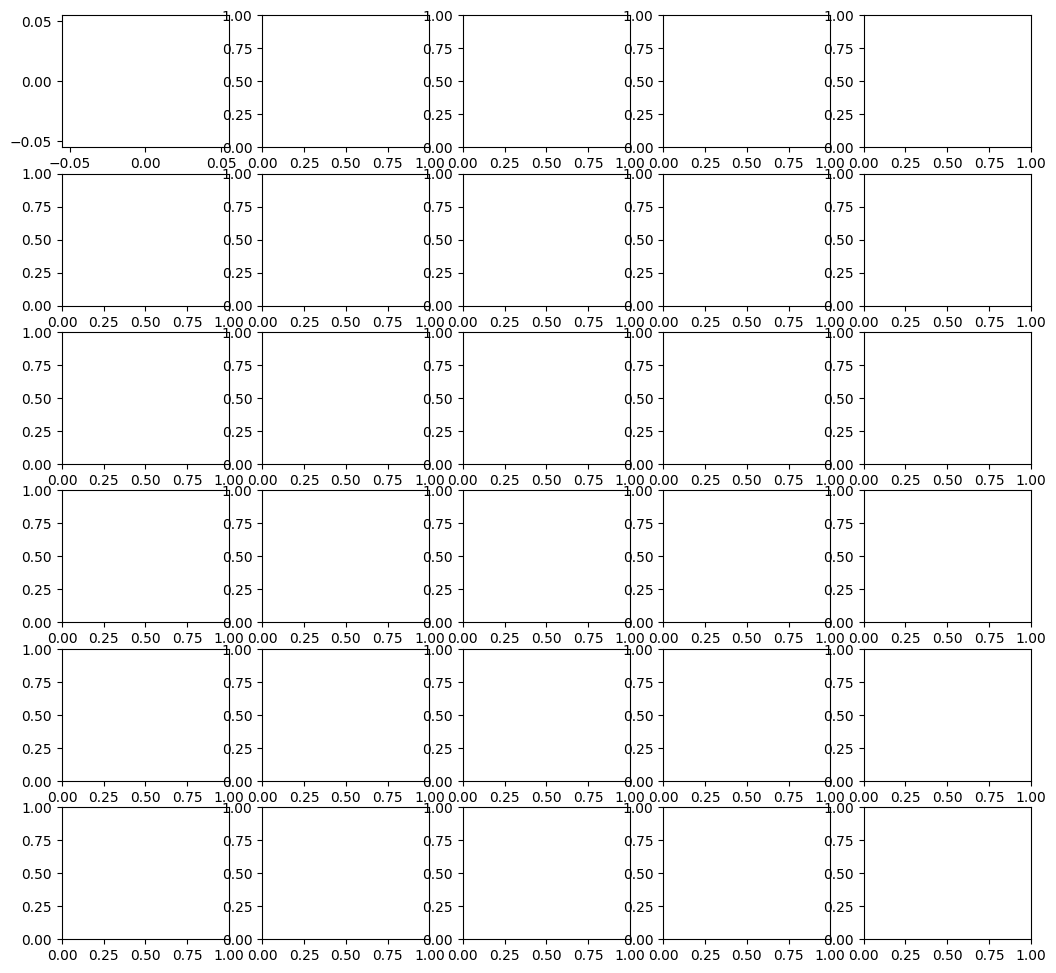

In [18]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# star formation history in log ang linear age space with cumulative figures
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.weights_thin, ppxf_weights.weights_thick, ppxf_weights.weights_bulge, ppxf_weights.weights_nuclear, ppxf_weights.cumulative_weights_2d],
                                          [true_weights.weights_thin, true_weights.weights_thick, true_weights.weights_bulge, true_weights.weights_nuclear, true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb[:, 0, 0], true_weights.yyb[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['age_stairs', 'age_stairs', 'age_cum', 'logage_stairs', 'logage_stairs', 'logage_cum'],
                            perbinsize_list=[True, False, None, True, False, None],
                            logmass_list=[False, False, False, False, False, False],
                            show_corr_list=[True, True, False, True, True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Thin disk', 'Thick disk', 'Upper Central', 'Inner Central', 'Global'],
                            direction='row', fraction_type=fraction_type
                           )
plt.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.5)
plt.savefig(fig_path_run + '/1dmfd_components_weightsmassperGyr_linlogage_' + cube_gist_run + '.pdf', dpi=500)


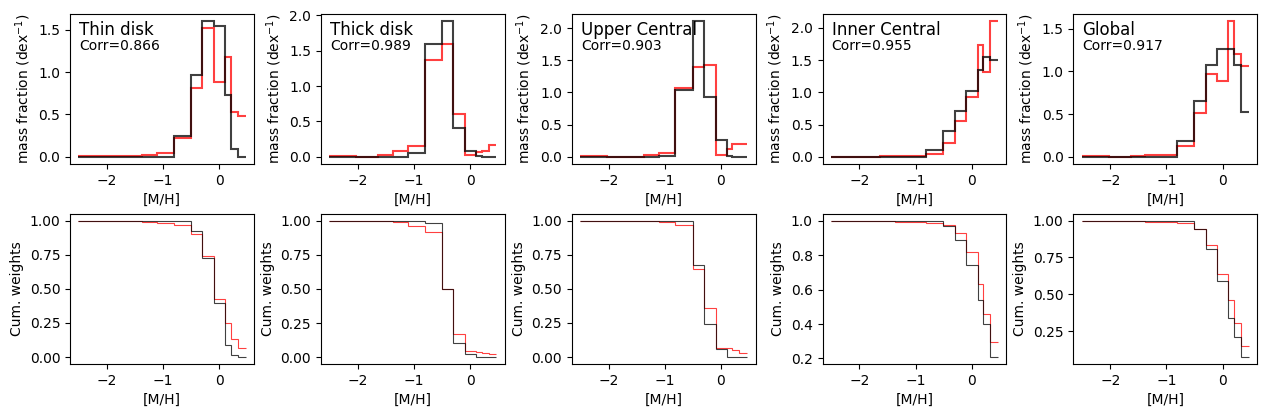

In [ ]:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# 1d metallicity distribution and cumulative distribution
fig = gist_mass_fraction_plot.plot_weights_1d_cases(weights_list=[[ppxf_weights.weights_thin, ppxf_weights.weights_thick, ppxf_weights.weights_bulge, ppxf_weights.weights_nuclear, ppxf_weights.cumulative_weights_2d],
                                          [true_weights.weights_thin, true_weights.weights_thick, true_weights.weights_bulge, true_weights.weights_nuclear, true_weights.cumulative_weights_2d]],
                            age_grid_list=[ppxf_weights.age_grid_2d[:, 0, 0], true_weights.age_grid_2d[:, 0, 0]],
                            metal_grid_list=[ppxf_weights.metal_grid_2d[0, :, 0], true_weights.metal_grid_2d[0, :, 0]],
                            age_gridsize_list=[ppxf_weights.yyb[:, 0, 0], true_weights.yyb[:, 0, 0]],
                            metal_gridsize_list=[ppxf_weights.xxb[0, :, 0], true_weights.xxb[0, :, 0]],
                            age_gridborder_list=[ppxf_weights.yb, true_weights.yb],
                            metal_gridborder_list=[ppxf_weights.xb, true_weights.xb],
                            plot_type_list=['metal_stairs', 'metal_cum'],
                            perbinsize_list=[True, False],
                            logmass_list=[False, False],
                            show_corr_list=[True, False],
                            color_list=['red', 'black'],
                            label_list=['PPXF results', 'True'],
                            text_list=['Thin disk', 'Thick disk', 'Upper Central', 'Inner Central', 'Global'],
                            direction='row', fraction_type=fraction_type
                           )
fig.tight_layout(pad=0.1, h_pad=0.5, w_pad=0.5)
fig.savefig(fig_path_run + '/1dmfd_components_weightsperdex_metal_' + cube_gist_run + '.pdf', dpi=500)

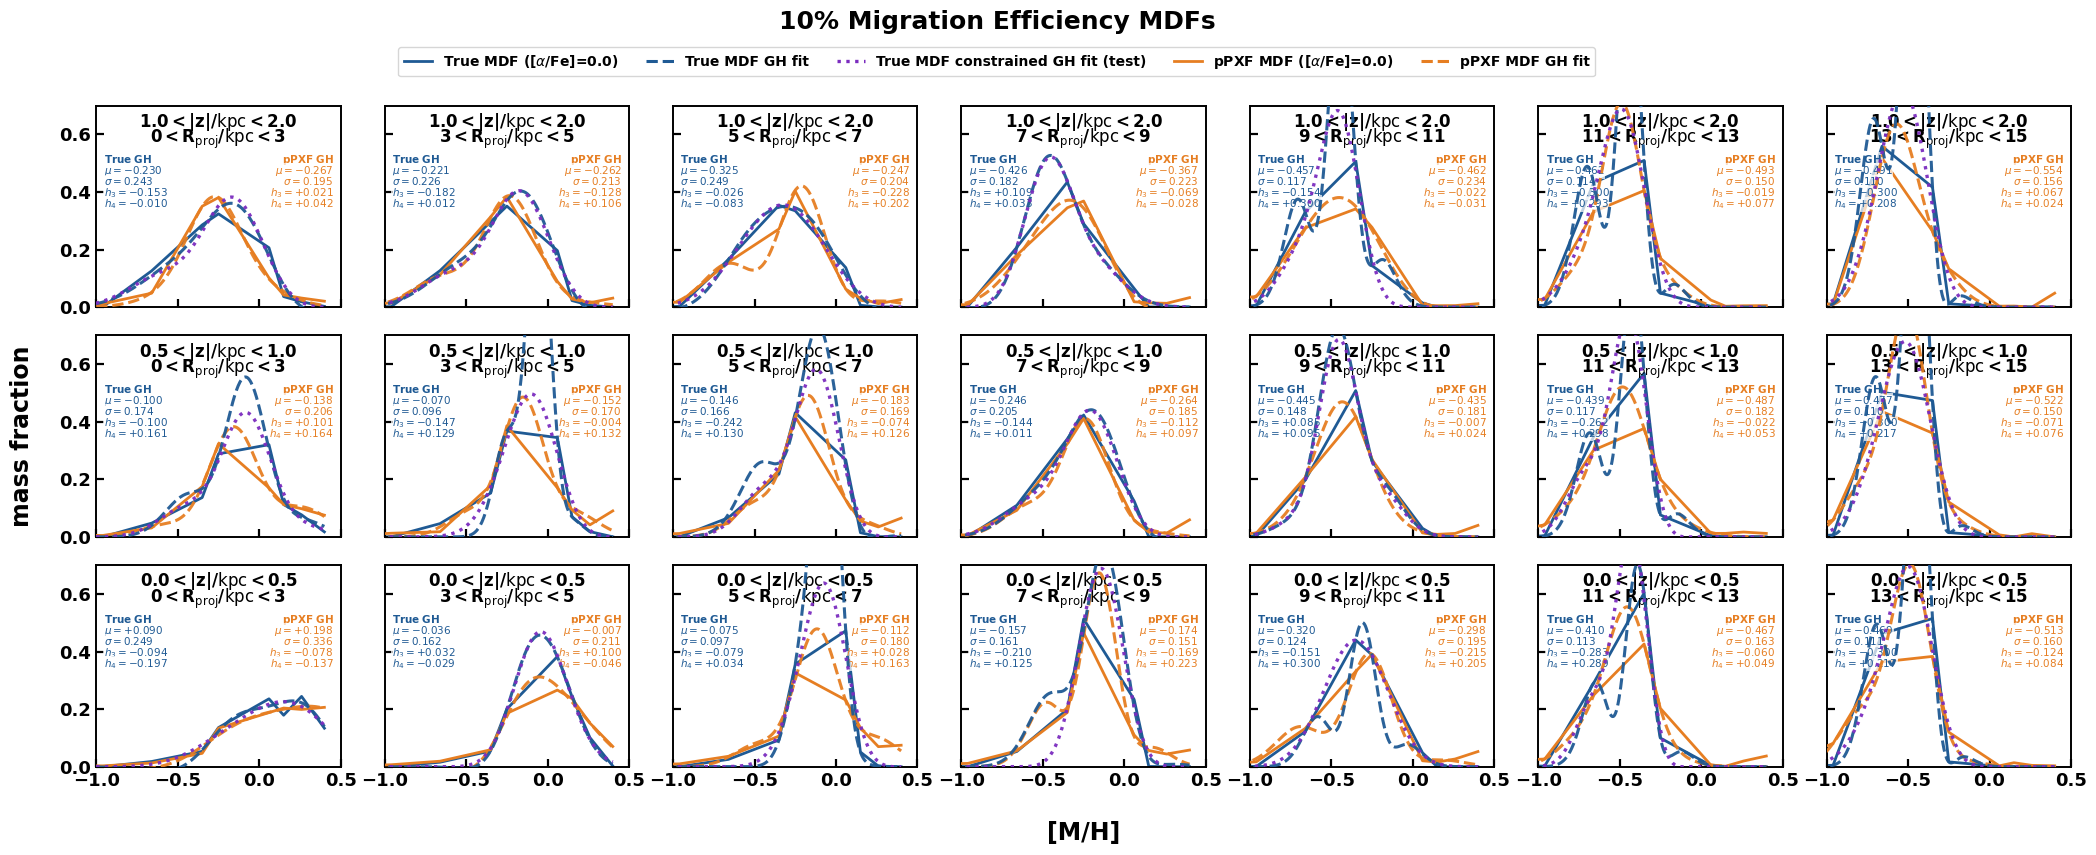

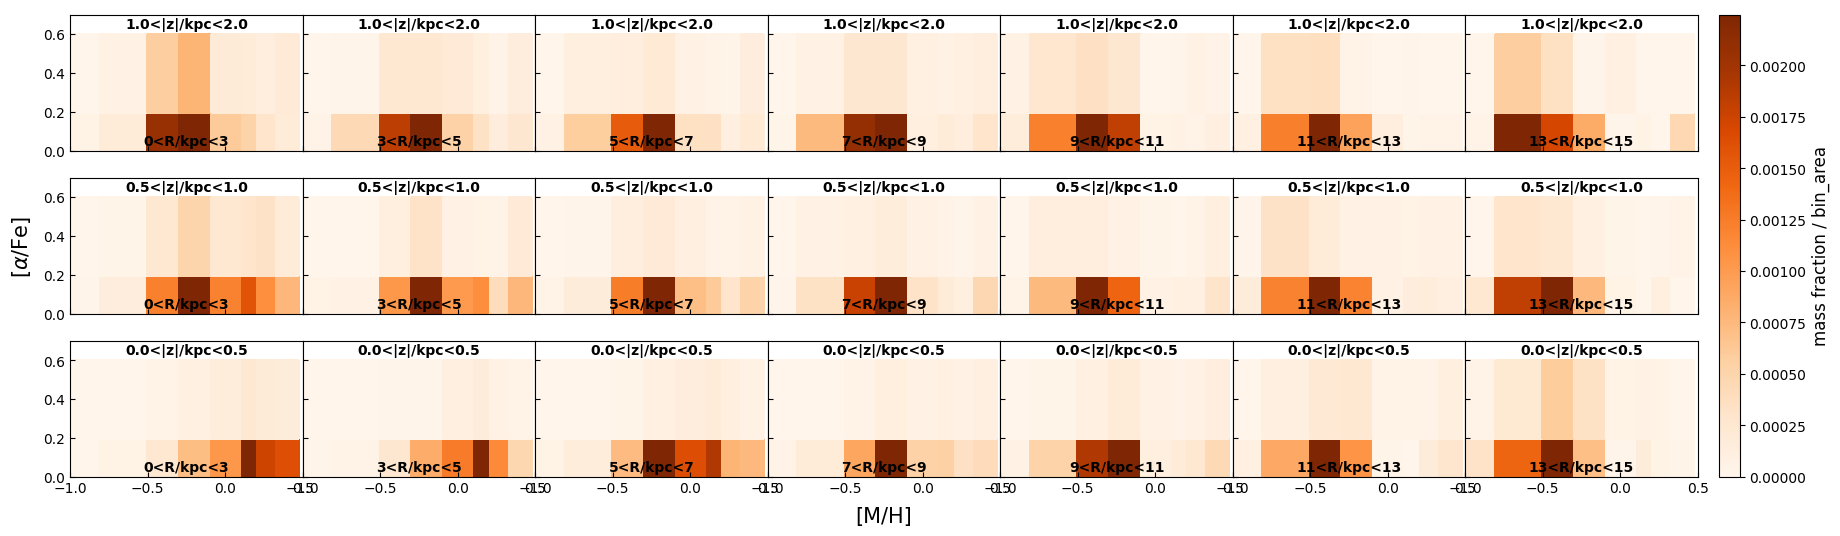

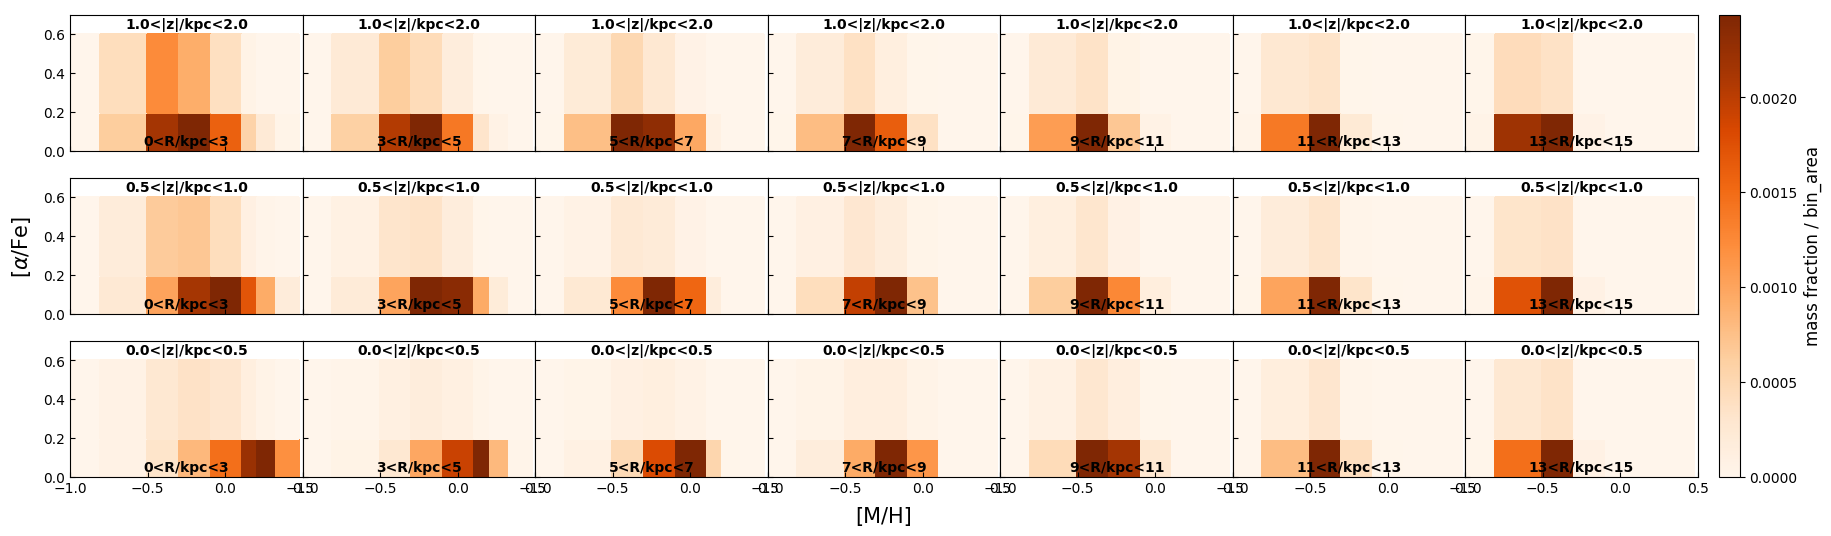

In [ ]:
# The Metallicity Distribution Functions (MDFs) and [alpha/Fe] vs [M/H] in R-Z bins

if ppxf_weights.reg_dim[2] > 1 and true_weights.reg_dim[2] > 1:

    d = 26500  # kpc
    rbin = np.array([0, 3, 5, 7, 9, 11, 13, 15])
    zbin = np.array([0, 0.5, 1, 2])

    fig_maprzhist, fit_results = gist_mass_fraction_plot.plot_mh_alpha_rz_hist(
        ppxf_weights.weights_values,
        true_weights.weights_values,
        rbin,
        zbin,
        d,
        ppxf_weights.reg_dim,
        true_weights.reg_dim,
        ppxf_weights.results_table,
        metal_grid=ppxf_weights.metal_grid_2d[0, :, 0],
        metal_grid_true=true_weights.metal_grid_2d[0, :, 0],
        fraction_type=fraction_type
    )

    fig_maprzhist.savefig(
        fig_path_run + '/alphafe_mh_rz_hist_' + cube_gist_run + '.pdf',
        dpi=500
    )


    fig_maprz = gist_mass_fraction_plot.plot_mh_alpha_rz(ppxf_weights.weights_values, rbin, zbin, d, ppxf_weights.results_table, reg_dim=ppxf_weights.reg_dim, \
                                                         metal_grid=ppxf_weights.metal_grid_2d[0, :, 0], alpha_grid=ppxf_weights.alpha_grid_2d[0, 0, :])
    fig_maprz.savefig(fig_path_run + '/alphafe_mh_rz_' + cube_gist_run + '.pdf', dpi=500)

    fig_maprz_true = gist_mass_fraction_plot.plot_mh_alpha_rz(true_weights.weights_values, rbin, zbin, d, ppxf_weights.results_table, reg_dim=true_weights.reg_dim, \
                                                              metal_grid=true_weights.metal_grid_2d[0, :, 0], alpha_grid=true_weights.alpha_grid_2d[0, 0, :])
    fig_maprz_true.savefig(fig_path_run + '/alphafe_mh_rz_true' + cube_gist_run + '.pdf', dpi=500)

CREATING FACE-ON MDFs — 10% MIGRATION EFFICIENCY

Model directory:
/Users/selilium/galcraft_test/test_gistplot/faceon/faceon_L0x0p1/gist/

GIST run:
resultsRevisedMEr1

Model identity:
  faceon_L0x0p1 = 10% migration efficiency
  resultsRevisedMEr1 = regularization R = 1

pPXF weights shape:
(2619, 1032)

True weights shape:
(2619, 1272)

Spatial table columns:
['ID', 'BIN_ID', 'X', 'Y', 'FLUX', 'SNR', 'XBIN', 'YBIN', 'SNRBIN', 'NSPAX']


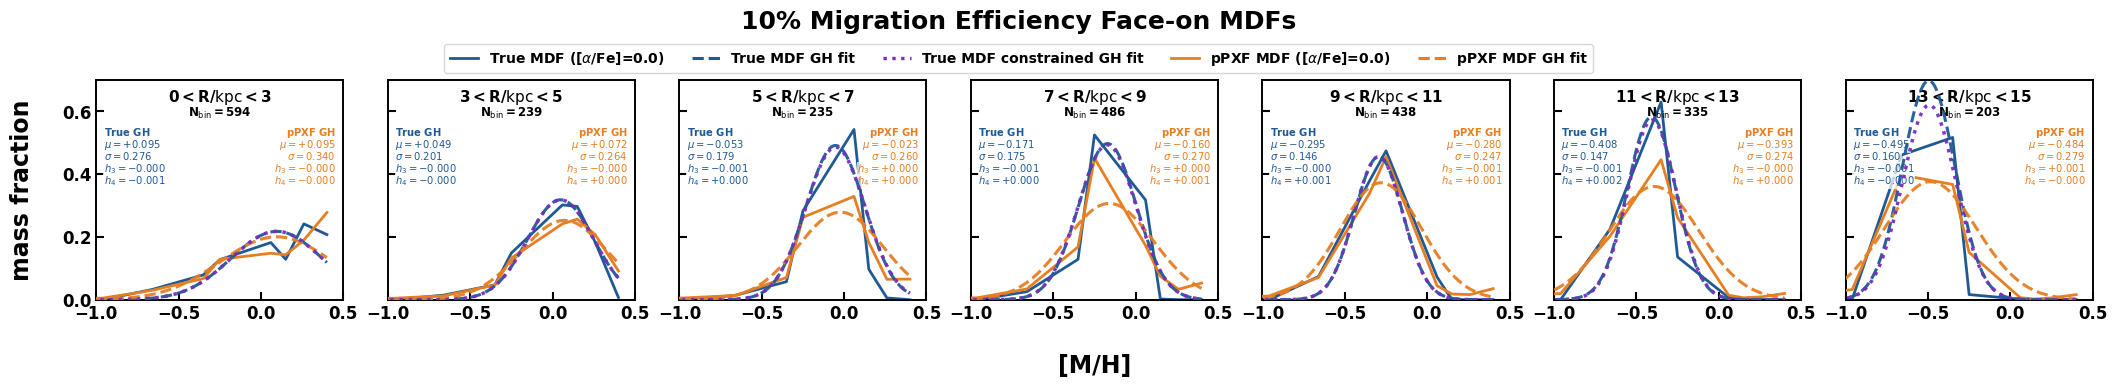


Saved PDF:
/Users/selilium/galcraft_test/test_gistplot/figs/faceon/faceon_L0x0p1/resultsRevisedMEr1/faceon_L0x0p1_R1_MDFs.pdf

Saved PNG:
/Users/selilium/galcraft_test/test_gistplot/figs/faceon/faceon_L0x0p1/resultsRevisedMEr1/faceon_L0x0p1_R1_MDFs.png

Face-on 10% MDFs completed successfully.


In [19]:
# ================================================================================================
# FACE-ON MDFs — 10% MIGRATION EFFICIENCY
# Model: faceon_L0x0p1
# GIST regularization: R = 1
# ================================================================================================

import importlib
import os
import numpy as np
import matplotlib.pyplot as plt

# Reload the updated plotting module so this notebook uses
# the current face-on radial binning and stabilized GH fitting.
importlib.reload(gist_mass_fraction_plot)

# Distance to the mock galaxy in kpc.
d = 26500.0

# True face-on galactocentric radial-bin edges in kpc.
# There are no |z| bins in the face-on orientation.
rbin_faceon = np.array(
    [
        0.0,
        3.0,
        5.0,
        7.0,
        9.0,
        11.0,
        13.0,
        15.0
    ],
    dtype=float
)

print("=" * 90)
print("CREATING FACE-ON MDFs — 10% MIGRATION EFFICIENCY")
print("=" * 90)

print(f"\nModel directory:\n{cube_gist_path}")
print(f"\nGIST run:\n{cube_gist_run}")

print("\nModel identity:")
print("  faceon_L0x0p1 = 10% migration efficiency")
print("  resultsRevisedMEr1 = regularization R = 1")

print("\npPXF weights shape:")
print(ppxf_weights.weights_values.shape)

print("\nTrue weights shape:")
print(true_weights.weights_values.shape)

print("\nSpatial table columns:")
print(ppxf_weights.results_table.colnames)

# Create the face-on MDF figure.
fig_faceon_mdf_10, faceon_fit_results_10 = (
    gist_mass_fraction_plot.plot_mh_alpha_r_hist_faceon(
        weights_values=ppxf_weights.weights_values,
        weights_true_values=true_weights.weights_values,

        rbin=rbin_faceon,
        d=d,

        reg_dim=ppxf_weights.reg_dim,
        reg_dim_true=true_weights.reg_dim,

        results_table=ppxf_weights.results_table,

        metal_grid=ppxf_weights.metal_grid_2d[0, :, 0],
        metal_grid_true=true_weights.metal_grid_2d[0, :, 0],

        fraction_type=fraction_type,

        figure_title=(
            "10% Migration Efficiency Face-on MDFs"
        ),

        alpha_index=0,

        x_center_arcsec=0.0,
        y_center_arcsec=0.0,

        # Show the purple constrained true-MDF diagnostic fit.
        include_true_constrained_fit=True
    )
)

plt.show()

# Save the figure.
os.makedirs(
    fig_path,
    exist_ok=True
)

pdf_path_10 = os.path.join(
    fig_path,
    "faceon_L0x0p1_R1_MDFs.pdf"
)

png_path_10 = os.path.join(
    fig_path,
    "faceon_L0x0p1_R1_MDFs.png"
)

fig_faceon_mdf_10.savefig(
    pdf_path_10,
    dpi=500,
    bbox_inches="tight"
)

fig_faceon_mdf_10.savefig(
    png_path_10,
    dpi=300,
    bbox_inches="tight"
)

print("\nSaved PDF:")
print(pdf_path_10)

print("\nSaved PNG:")
print(png_path_10)

print("\nFace-on 10% MDFs completed successfully.")